# Load portion

In [2]:
# i understand the api key being public is very poor practise, but i have to...
# ...get this done 

In [ ]:
import requests
import time
import duckdb
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from prefect import task, flow
import matplotlib.pyplot as plt
import textwrap
import logging

#import os

# configuring the logging mechanism
logging.basicConfig(
    filename='load.log',
    filemode="a",
    style="{", 
    datefmt="%Y-%m-%d-%H:%M:%x", 
    level="INFO"
)
logger = logging.getLogger(__name__)


# fetching secret key from our environment.
# of course i'm not committing it to this repo
#my_api_key = os.environ.get("9f2cea00198d4c24955ae9d517cf77fe")

# list of news source names for the API to call from
news_source_names = ["cnn", "fox-news", "the-wall-street-journal", "abc-news", "associated-press",
"cbs-news", "the-huffington-post", "breitbart-news", "msnbc", "the-american-conservative",
                    "the-verge", "national-review"]

# path to our database, where our sql tables will be located
db_path = "DS4320_project1.duckdb"

# defining load function 
def load_relevant_data():
    con = duckdb.connect(db_path)
    logger.info("connected to duckdb instance.") 
    try: 
        # create SQL table for news articles and their headlines
        con.execute(f"""
                    CREATE TABLE IF NOT EXISTS NEWS_ARTICLES(
                        source_id VARCHAR,
                        source_name VARCHAR,
                        article_title VARCHAR,
                        article_pubdate TIMESTAMP, 
                        article_url VARCHAR
                    )
                    """)
        logger.info("created empty SQL table for news article details.") 
        
        # creating SQL table for each news source and reliability scores and bias scores
        con.execute(f"""
                    CREATE TABLE IF NOT EXISTS SOURCE_AND_RELIABILITY(
                    source_id VARCHAR, 
                    source_bias DOUBLE,
                    source_reliability DOUBLE, 
                    reliability_threshold_diff DOUBLE, 
                    unreliability_threshold_diff DOUBLE 
                    )
                    """)
        logger.info("created empty SQL table for news source bias/reliability details.") 
       
        # creating SQL table for the sentiments in article headlines
        con.execute(f"""
                    CREATE TABLE IF NOT EXISTS HEADLINES_SENTIMENTS(
                    source_id VARCHAR, 
                    article_title VARCHAR, 
                    title_sentiment DOUBLE
                    )
                    """)
        logger.info("created empty SQL table for headline sentiment details.") 

        # creating SQL table for source identificatory details
        con.execute(f"""
                    CREATE TABLE IF NOT EXISTS SOURCE_IDENTIFICATION(
                    source_id VARCHAR, 
                    source_name VARCHAR, 
                    source_url VARCHAR
                    )
                    """)
        logger.info("created SQL table for news sources' identificatory details.") 
        
        # populating SQL table for source bias and reliability 
        source_bias_and_reliability = pd.read_csv("https://raw.githubusercontent.com/pollyannafx/datascience-sandbox/refs/heads/main/source-bias-reliability.csv")
        source_bias_and_reliability_df = pd.DataFrame(source_bias_and_reliability)
        con.execute(f"INSERT INTO SOURCE_AND_RELIABILITY SELECT * FROM source_bias_and_reliability_df")
        logger.info("populated SQL table for source bias and reliability.") 
        
        ############## articles we will be fetching from APIs ############
        source_names_and_ids = []
        news_articles = []
        headline_sentiments = []
    
        # defining our sntiment analysis tool 
        analyzer = SentimentIntensityAnalyzer()
    
        # connecting to master newsAPI 
        response1 = requests.get("https://newsapi.org/v2/sources?language=en&country=us&apiKey=9f2cea00198d4c24955ae9d517cf77fe")
        logger.info("connected to master newsAPI.") 

        # retrieving data from newsAPI 
        open_source_page1 = response1.json()
        logger.info("retrieved info from master newsAPI.") 

        # retrieving individual pieces of identificatory information 
        sources_more = open_source_page1.get("sources", "") 
        for source in sources_more:
            source_id = source.get("id", "") 
            source_name = source.get("name", "")
            source_url = source.get("url", "")
              
            # appending to dictionary 
            source_names_and_ids.append({
                "source_id": source_id, 
                "source_name": source_name,
                "source_url": source_url
            })

        # populating SQL table for news source identificatory information 
        source_names_and_ids_df = pd.DataFrame(source_names_and_ids)
        con.execute(f"INSERT INTO SOURCE_IDENTIFICATION SELECT * FROM source_names_and_ids_df")
        logger.info("populated SQL table for news sources' identificatory details.") 
    
                                   
        # initialising link for per-source API  
        for source in news_source_names: 
            base_url = f"https://newsapi.org/v2/everything?sources={source}&language=en&apiKey=9f2cea00198d4c24955ae9d517cf77fe"
    
            query_params_1 = {
                "sources": source,
                "sortBy": "top",
                "apiKey": "9f2cea00198d4c24955ae9d517cf77fe"
            } 
        
          ### news_articles
            # connecting to per-source API 
            response2 = requests.get(url = base_url, params = query_params_1)
            logger.info(f"connected to {source} newsAPI.") 
            
            # retrieving info from per-source API 
            open_source_page2 = response2.json()
            logger.info(f"retrieved info from {source} newsAPI.") 

            # fetching all articles for a specific source
            articles_list = open_source_page2.get("articles","")
            # retrieving information from each 
            for article in articles_list:
                source =  article.get("source", "")
                source_id = source.get("id", "")
                source_name = source.get("name", "")
                article_title = article.get("title", "")
                article_pubdate = article.get("publishedAt", "")
                article_url = article.get("url", "") 
                
                # appending information from the articles to a dictionary
                news_articles.append({
                    "source_id": source_id,
                    "source_name": source_name,
                    "article_title": article_title,
                    "article_pubdate": article_pubdate, 
                    "article_url": article_url
                })

                # performing sentiment analysis on the articles' headlines 
                title_sentiment = analyzer.polarity_scores(article_title)["compound"]
                # taking the absolute value 
                title_sentiment = abs(title_sentiment)
                logger.info(f"conducted sentiment analysis on article titles from {source}.") 

                # appending to dictionary 
                headline_sentiments.append({
                    "source_id": source_id,
                    "article_title": article_title,
                    "title_sentiment": title_sentiment
                    })

        # creating dataframes for both article details and for sentiments of headlines 
        headline_sentiments_df = pd.DataFrame(headline_sentiments)  
        news_articles_df = pd.DataFrame(news_articles)

        # populating SQL table for news article details 
        con.execute(f"INSERT INTO NEWS_ARTICLES SELECT * FROM news_articles_df")
        logger.info(f"populated SQL table for news articles with articles from {source}.") 

        # populating SQL tables for headline sentiments
        con.execute(f"INSERT INTO HEADLINES_SENTIMENTS SELECT * FROM headline_sentiments_df")
        logger.info(f"populated SQL table for headline sentiments with headline sentiments from {source}.") 
        
        # creating dictionary of dataframes. i used these when conducting EDA 
        tables_dict = {"news_articles_df":news_articles_df, "source_names_and_ids_df":source_names_and_ids_df,
                        "source_bias_and_reliability_df":source_bias_and_reliability_df, "headline_sentiments_df":headline_sentiments_df}
        return tables_dict


    # error handling 
    except Exception as e:
        print(f"An error occurred: {e}")
        logger.error(f"An error occurred: {e}")

# so it works 
if __name__ == '__main__':
    load_relevant_data()

In [4]:
# loading relevant data
tables_dict = load_relevant_data()

An error occurred: Invalid Input Error: Need a DataFrame with at least one column


04:45:01.229 | ERROR   | __main__ - An error occurred: Invalid Input Error: Need a DataFrame with at least one column

# Analysis portion

Saved plot to reliability_sentiment.png


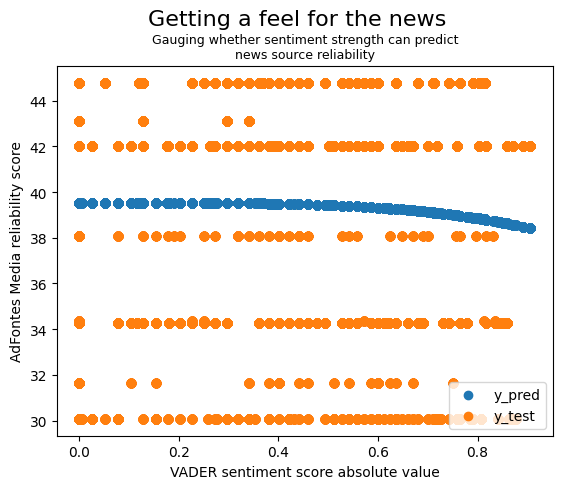

In [36]:
import logging
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split

# configuring the logging mechanism
logging.basicConfig(
    filename='analysis.log',
    filemode="a",
    style="{", 
    datefmt="%Y-%m-%d-%H:%M:%x", 
    level="INFO"
)
logger = logging.getLogger(__name__)

def analyse_relevant_data(): 
    # connecting to duckdb instance 
    con = duckdb.connect(db_path)
    try:
        # joining tables for analysis 
        df = con.execute(f"""SELECT 
        s.source_id,
        h.title_sentiment,
        s.source_reliability
        FROM HEADLINES_SENTIMENTS h 
        JOIN SOURCE_AND_RELIABILITY s
        ON h.source_id = s.source_id
        ;""").df()
        logger.info("joined tables for analysis") 
        
        # feature and target matrices 
        X = df.iloc[:,1:2]
        y = df.iloc[:,-1:]
        logger.info("created feature and target matrices") 

        # Create training and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
        logger.info("created training and test sets") 
 
        # designing pipeline 
        final_pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=9, include_bias=False)),
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=0.016681))
        ])
        logger.info("designed pipeline") 

        # finally fitting polynomial reg pipeline 
        final_pipeline.fit(X_train, y_train)
        y_pred = final_pipeline.predict(X_test)
        logger.info("fit the polynomial reg pipeline") 
        logger.info("output predictions") 

        # creating scatterplot 
        plt.scatter(x=X_test, y=y_pred)
        plt.scatter(x=X_test, y=y_test) 
        plt.xlabel("VADER sentiment score absolute value") 
        plt.ylabel("AdFontes Media reliability score") 
        plt.suptitle("Getting a feel for the news", y=0.999, fontsize=16)
        plt.title("Gauging whether sentiment strength can predict\nnews source reliability", fontsize=9)
        plt.legend(labels=["y_pred","y_test"], loc="lower right")
        logger.info("created graph") 
        
        # making a png image of our graph. 
        output_path = "reliability_sentiment.png"
        plt.savefig(output_path, format="png")
        print(f"Saved plot to {output_path}")
        logger.info("saved graph") 

        # 'showing' graph 
        plt.show()

        # output path to our graph (it's a png image now) 
        return output_path
        
    # error handling
    except Exception as e:
        print(f"An error occurred: {e}")
        logger.error(f"An error occurred: {e}")

# so it will actually work 
if __name__ == '__main__':
    analyse_relevant_data()

# Analysis Rationale

Because I wanted my input data to be labelled, I opted for supervised learning; and because I was assessing numerical data, I opted for regression. When looking at relationships between the features themselves, it was obvious the relationship between title sentiments and the bias reliability of the articles would be non-linear, so polynomial regression in addition to lasso was used.<br>
SciKit's Polynomial Regression package allows for us to change the *alpha* value (the penalty term), in addition to the *degree* value (which dictates the degree of our resultant polynomial best-fit equation). Using GridSearchCV, we can assess multiple candidates for our alpha and degree value, selecting the combination that results in the lowest mean squared error.<br>
Article sentiment (without other features) was used in my polynomial regression model because attributes such as source_bias were specifically pulled from Ad Fontes Media, and not every news article the prototype would theoretically assess (upon being deployed) would have a bias score available. The model was specifically trained on absolute values of article sentiment (instead of the raw value) because strong sentiments can be used to infer sensationalised news. 

https://towardsdatascience.com/simple-regularized-linear-and-polynomial-regression-37d0d634ece3/

In [6]:
# tool for viz 
import seaborn as sns 

In [7]:
# Defining the df we will use - reliability vs sentiment
headline_sentiment = tables_dict["headline_sentiments_df"]
source_bias_and_reliability = tables_dict["source_bias_and_reliability_df"]
sentiments_for_viz_2 = pd.merge(headline_sentiment[["source_id","title_sentiment"]], source_bias_and_reliability[["source_id", "source_bias", "source_reliability"]], on="source_id")
sentiments_for_viz_2 = sentiments_for_viz_2.groupby("source_id").mean().reset_index() 
sentiments_for_viz_2.head()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# reliability vs sentiment scatter
sns.scatterplot(sentiments_for_viz_2, x="source_reliability", y="title_sentiment", hue="source_id")


In [ ]:
# Defining the df we will use - bias vs sentiment
headline_sentiment = tables_dict["headline_sentiments_df"]
source_bias = tables_dict["source_bias_and_reliability_df"]
sentiments_for_viz_3 = pd.merge(headline_sentiment[["source_id","title_sentiment"]], source_bias_and_reliability[["source_id", "source_bias"]], on="source_id")
sentiments_for_viz_3 = sentiments_for_viz_3.groupby("source_id").mean().reset_index() 
sentiments_for_viz_3.head()

sns.scatterplot(sentiments_for_viz_3, x="source_bias", y="title_sentiment", hue="source_id")

In [ ]:
# bias vs sentiment scatter
source_bias = tables_dict["source_bias_and_reliability_df"]

sns.scatterplot(source_bias, x="source_bias", y="source_reliability", hue="source_id")

In [ ]:
# selecting just these columns to avoid multiple collinearity as much...
# ...as possible as some columns are linear combos of each other 
table_for_ml_2 =pd.merge(headline_sentiment[["source_id","title_sentiment"]], source_bias_and_reliability[["source_id", "source_reliability"]], on="source_id")
table_for_ml_2.head()

In [ ]:
from sklearn.model_selection import train_test_split
# you need to change this. 
X = table_for_ml_2.iloc[:,1:-1]
y = table_for_ml_2.iloc[:,-1:]

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
# whats a good test size

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
#from sklearn.utils.testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

# ok grandpa lets get you to bed: 
#warnings.filterwarnings("ignore")

# Pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

# Parameter grid
param_grid = {
    'poly__degree': np.arange(1, 11),
    'lasso__alpha': np.logspace(-4, 1, 10)
}

# Grid search with MSE scoring
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_mean_squared_error',  # stays as MSE
    n_jobs=-1,
    cv=4
)

# Fit
grid_search.fit(X_train, y_train)

# Collect results
results = pd.DataFrame(grid_search.cv_results_)
results = results[['param_lasso__alpha', 'param_poly__degree', 'mean_test_score']]
results.columns = ['alpha', 'degree', 'MSE']
results['MSE'] = -results['MSE']  # flip sign back to positive

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.axes(projection='3d')

z = results["MSE"]
x = results["alpha"]
y = results["degree"]

ax.scatter(x, y, z, 'green')
ax.view_init(elev=6, azim=130)
ax.set_title('MSE based on different model parameters', size=16, y=0.9)
ax.set_xlabel("alpha value")
ax.set_ylabel("polynomial degree")
ax.set_zlabel("MSE",rotation=90)
plt.show()

In [ ]:
# we need to: 
    # view what alpha value is closest to zero 
    # view what polynomial degree doesn't overfit 
results["MSE"].idxmin()

In [ ]:
results.iloc[48, :]

# this is the model we will use 

In [ ]:
final_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=9, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.016681))
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

plt.scatter(x=X_test["title_sentiment"], y=y_pred)
plt.scatter(x=X_test["title_sentiment"], y=y_test) 

plt.legend(labels=["y_pred","y_test"])
plt.show()